# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ames_housing.csv")

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()

데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
-> 생활면적이 1단위 증가할 때 마다 모델이 예측하는 매매가격이 평균적으로 약 107.13만큼 증가한다는 의미

- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
-> 생활면적이 0일 때 예측가격 약 18,569를 의미한다.
-> 면적이 0인 주택은 관측 범위나 현실적 분석 대상과는 거리가 있기 때문에 과도한 해석을 피해야 한다.

- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?
-> 실제값과 예측값의 차이인 잔차를 제곱해 모두 더한 SSE값이 가장 작아지는 기울기와 절편을 선택한다.


x 평균 = 1515.46
y 평균 = 180921.20
기울기 beta1 = 107.1304
절편 beta0 = 18569.0259
회귀식: SalePrice = 18569.03 + 107.13 × GrLivArea
GrLivArea=1500 예측가격 = 179,264.56


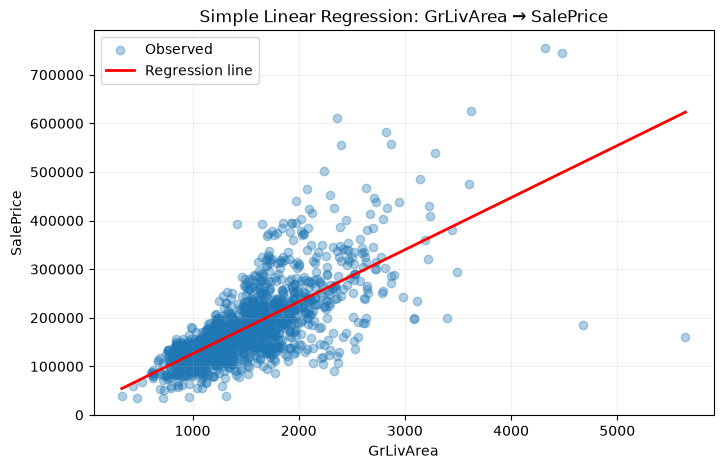

In [2]:
# 여기에 코드를 작성하세요.

reg_data = df[["GrLivArea", "SalePrice"]].dropna()
x = reg_data["GrLivArea"].to_numpy(dtype=float)
y = reg_data["SalePrice"].to_numpy(dtype=float)

x_mean = x.mean()
y_mean = y.mean()

beta1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta0 = y_mean - beta1 * x_mean

target_area = 1500
predicted_price_1500 = beta0 + beta1 * target_area

print(f"x 평균 = {x_mean:.2f}")
print(f"y 평균 = {y_mean:.2f}")
print(f"기울기 beta1 = {beta1:.4f}")
print(f"절편 beta0 = {beta0:.4f}")
print(f"회귀식: SalePrice = {beta0:.2f} + {beta1:.2f} × GrLivArea")
print(f"GrLivArea=1500 예측가격 = {predicted_price_1500:,.2f}")

x_line = np.linspace(x.min(), x.max(), 200)
y_line = beta0 + beta1 * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, label="Observed")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Simple Linear Regression: GrLivArea → SalePrice")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
-> 현재 데이터에서 매매가격 전체 변동의 약 50.2%를 생활면적과의 선형회귀 모델이 설명한다는 의미

- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
-> 아닙니다. 양의 잔차와 음의 잔차가 상쇄될 수 있다. 잔차의 크기와 패턴 파악이 추가적으로 필요하다.

- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
-> 높은 예측가격 구간에서 잔차의 퍼짐이 커지는 경향과 회귀선에서 매우 멀리 떨어진 관측치가 보인다.

- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?
-> 생활면적과 가격의 양의 관계 및 약 절반의 변동성을 설명하지만, 나머지 약 49.8%는 설명하지 못했다
-> 오차의 퍼짐과 극단값도 차이가 컸다.
-> 기본 모델로 모델링을 진행할 수 있다는 것을 확인할 수 있다.


SSE = 4,584,171,086,113.13
SST = 9,207,911,334,609.98
R² = 0.5021
잔차 평균 = 0.0000000000
MAE = 37,638.73

[절대잔차가 가장 큰 관측치]
GrLivArea = 5642
실제가격 = 160,000.00
예측가격 = 622,998.51
잔차 = -462,998.51


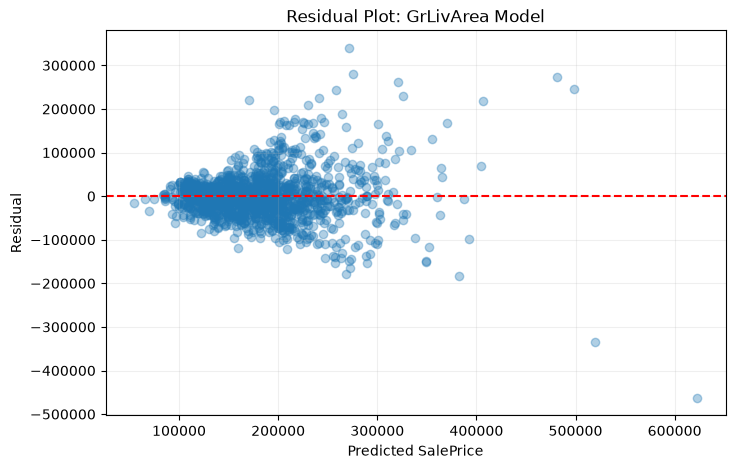

In [3]:
# 여기에 코드를 작성하세요.
y_pred = beta0 + beta1 * x
residuals = y - y_pred

sse = np.sum(residuals ** 2)
sst = np.sum((y - y_mean) ** 2)
r_squared = 1 - sse / sst
residual_mean = residuals.mean()
mae = np.mean(np.abs(residuals))

max_error_idx = np.argmax(np.abs(residuals))

print(f"SSE = {sse:,.2f}")
print(f"SST = {sst:,.2f}")
print(f"R² = {r_squared:.4f}")
print(f"잔차 평균 = {residual_mean:.10f}")
print(f"MAE = {mae:,.2f}")
print("\n[절대잔차가 가장 큰 관측치]")
print(f"GrLivArea = {x[max_error_idx]:.0f}")
print(f"실제가격 = {y[max_error_idx]:,.2f}")
print(f"예측가격 = {y_pred[max_error_idx]:,.2f}")
print(f"잔차 = {residuals[max_error_idx]:,.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residual Plot: GrLivArea Model")
plt.grid(alpha=0.2)
plt.show()


---)

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?  
-> 기울기 : x가 1만큼 갔을 때 y값, 건축연도가 1년 늘어날 때마다 예측 매매가격이 평균적으로 약 1,375.37만큼 증가한다는 의미  
-> 절편 : x가 0일때의 y값, 수학적으로 건축연도가 0년일 때의 예측 매매가격(-2,530,308.25)을 의미하지만  
-> 건축연도가 0인 주택은 관측 범위나 현실적 분석 대상과는 거리가 있기 때문에 과도한 해석을 피해야 함.


- $R^2$을 기준으로 모델의 설명력은 어떠한가요?  
-> R²=0.2734 설명력이 약 27.3%수준으로 낮은 편에 속함   

- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?  
-> 오른쪽에서 잔차의 퍼짐 정도가 넓으며, 선에서 크게 벗어난 관측치도 보임  
-> 모델이 일부 구간에서 예측 오차가 크게 벌어져 주의가 필요

- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.  
-> 건축 연도만으로는 약 27%의 설명력을 가지고 있으므로 추가적인 요인이 있는지 파악해보아야함

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


x(YearBuilt) 평균 = 1971.27
y(SalePrice) 평균 = 180921.20
기울기 beta1_year = 1375.3735
절편 beta0_year = -2530308.2457
회귀식: SalePrice = -2530308.25 + 1375.37 × YearBuilt
YearBuilt=2000 예측가격 = 220,438.69

SSE = 6,690,269,293,939.84
SST = 9,207,911,334,609.98
R² = 0.2734
잔차 평균 = 0.0000000003
MAE = 47,024.01

[절대잔차가 가장 큰 관측치]
YearBuilt = 1994
실제가격 = 755,000.00
예측가격 = 212,186.45
잔차 = 542,813.55


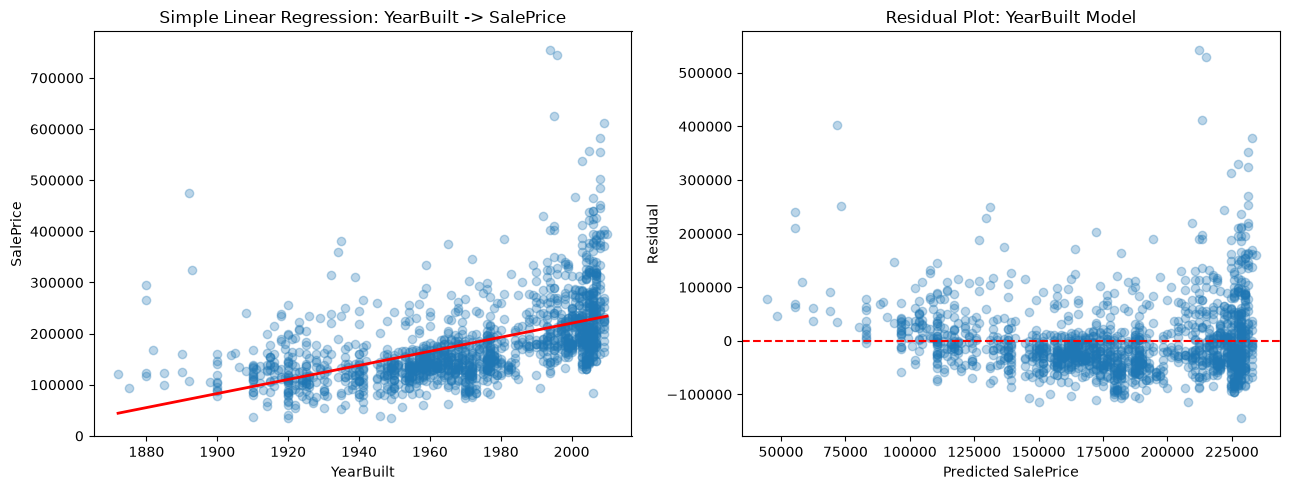

In [4]:

# ===== 1. 최소제곱법으로 기울기/절편 계산 =====
reg_data_year = df[["YearBuilt", "SalePrice"]].dropna()
x_year = reg_data_year["YearBuilt"].to_numpy(dtype=float)
y_year = reg_data_year["SalePrice"].to_numpy(dtype=float)

x_year_mean = x_year.mean()
y_year_mean = y_year.mean()

beta1_year = np.sum((x_year - x_year_mean) * (y_year - y_year_mean)) / np.sum((x_year - x_year_mean) ** 2)
beta0_year = y_year_mean - beta1_year * x_year_mean

print(f"x(YearBuilt) 평균 = {x_year_mean:.2f}")
print(f"y(SalePrice) 평균 = {y_year_mean:.2f}")
print(f"기울기 beta1_year = {beta1_year:.4f}")
print(f"절편 beta0_year = {beta0_year:.4f}")
print(f"회귀식: SalePrice = {beta0_year:.2f} + {beta1_year:.2f} × YearBuilt")

# ===== 3. YearBuilt=2000 예측가격 =====
target_year = 2000
predicted_price_2000 = beta0_year + beta1_year * target_year
print(f"YearBuilt=2000 예측가격 = {predicted_price_2000:,.2f}")

# ===== 2. 예측값, 잔차, SSE, SST, R^2 =====
y_pred_year = beta0_year + beta1_year * x_year
residuals_year = y_year - y_pred_year

sse_year = np.sum(residuals_year ** 2)
sst_year = np.sum((y_year - y_year_mean) ** 2)
r_squared_year = 1 - sse_year / sst_year
residual_mean_year = residuals_year.mean()
mae_year = np.mean(np.abs(residuals_year))

print(f"\nSSE = {sse_year:,.2f}")
print(f"SST = {sst_year:,.2f}")
print(f"R² = {r_squared_year:.4f}")
print(f"잔차 평균 = {residual_mean_year:.10f}")
print(f"MAE = {mae_year:,.2f}")

# 절대잔차가 가장 큰 관측치
max_error_idx_year = np.argmax(np.abs(residuals_year))
print("\n[절대잔차가 가장 큰 관측치]")
print(f"YearBuilt = {x_year[max_error_idx_year]:.0f}")
print(f"실제가격 = {y_year[max_error_idx_year]:,.2f}")
print(f"예측가격 = {y_pred_year[max_error_idx_year]:,.2f}")
print(f"잔차 = {residuals_year[max_error_idx_year]:,.2f}")

# ===== 4. 산점도+회귀직선, 잔차 플롯 =====
x_line_year = np.linspace(x_year.min(), x_year.max(), 200)
y_line_year = beta0_year + beta1_year * x_line_year

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x_year, y_year, alpha=0.3)
axes[0].plot(x_line_year, y_line_year, color="red", linewidth=2)
axes[0].set_xlabel("YearBuilt")
axes[0].set_ylabel("SalePrice")
axes[0].set_title("Simple Linear Regression: YearBuilt -> SalePrice")

axes[1].scatter(y_pred_year, residuals_year, alpha=0.3)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted SalePrice")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot: YearBuilt Model")

plt.tight_layout()
plt.show()

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.
